# Introduction

A group of UBC computer science students, named The Pacific Laboratory for Artificial Intelligence (PLAI), are conducting research on player actions in their own MineCraft server, PLAIcraft. This is being done with hopes of developing an advanced AI tool, also known as embodied AI, to implement in the video game. Additionally, supporting the server requires adequate information about the amount and type of players for recruitment efforts. As such, data on players and their gameplay is being collected through this MineCraft server.  


## Data Description (subtitle tbd)

In [12]:
library(tidyverse)
library(tidymodels)

players <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/players.csv")
sessions <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/sessions.csv")

sessions_compressed <- sessions |>
    select(hashedEmail) |>
    group_by(hashedEmail) |>
    summarize(session_count = n())

combined_data <- players |>
    inner_join(sessions_compressed)

head(combined_data)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(hashedEmail)`


experience,subscribe,hashedEmail,played_hours,name,gender,Age,session_count
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,27
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,3
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,1
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,1
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,1
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21,1


## Summary statistics

We will now acquire relevant summary statistiscs for our analysis from the combined dataset created above. We would like to look at the median and mean of player age, as well as the mean # of session per player.

In [13]:
# summary of player ages
summary_age <- players |>
    mutate(avg_age = mean(Age, na.rm = TRUE), 
            med_age = median(Age, na.rm = TRUE)) |>
    select(avg_age, med_age) |>
    slice(1) |>
    mutate(avg_age = round(avg_age, 2))
summary_age

avg_age,med_age
<dbl>,<dbl>
21.14,19


The average age is roughly 21 years old while the median is 19. This suggests that we have majority individuals in their teens and twenties participating.

In [14]:
# summary of player sessions
summary_session <- combined_data |>
        mutate(avg_session = mean(session_count), na.rm = TRUE) |>
        select(avg_session) |>
        slice(1) |>
        mutate(avg_session = round(avg_session, 2))
summary_session

avg_session
<dbl>
12.28


The average was roughly 12 sessions per player.

# Methods

## Determining the method for data analysis 

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


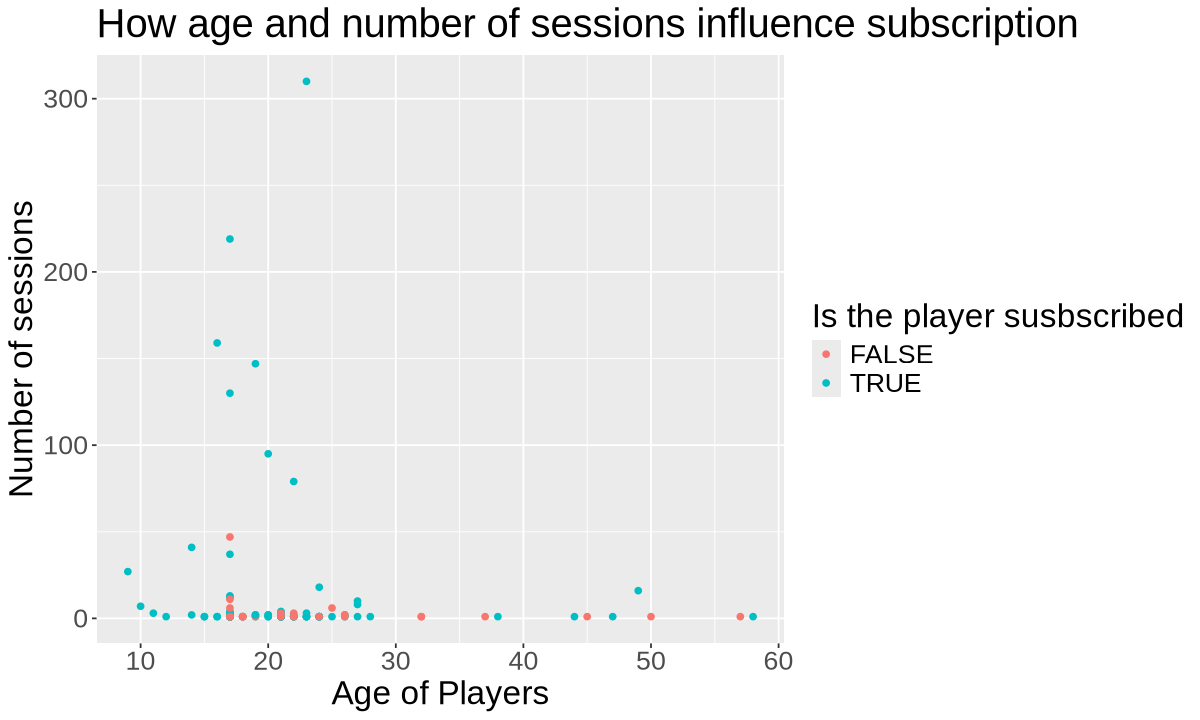

In [6]:
options(repr.plot.width=10, repr.plot.height=6)

plot_of_age_vs_subscription<- ggplot(combined_data, aes(x = Age, y = session_count))+
geom_point(aes(colour = subscribe))+ 
xlab("Age of Players")+ 
ylab("Number of sessions")+ 
ggtitle("How age and number of sessions influence subscription")+
labs(colour= "Is the player susbscribed")+
theme(text = element_text(size = 20))

plot_of_age_vs_subscription

[insert reasoning for this plot and what it shows]

## Renaming the Subscribe observations 

In [7]:
combined_data <- combined_data |>
  mutate(subscribe = factor(subscribe))


[insert explanation of why this is necessary]

## Splitting the data for training and analysis 

In [8]:
minecraft_split<- initial_split(combined_data, prop = 0.75, strata = subscribe)
minecraft_training<- training(minecraft_split) 
minecraft_testing<- testing(minecraft_split)

## Making a recipe

In [9]:
minecraft_vfold<- vfold_cv(minecraft_training, v= 5, strata = subscribe)

minecraft_recipe<- recipe(subscribe ~ Age + session_count, data = minecraft_training)|> 
step_scale(Age, session_count)|> 
step_center(Age, session_count)

minecraft_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 2



── Operations 

• Scaling for: Age and session_count

• Centering for: Age and session_count



## Creating the K-NN classifier 

In [10]:
minecraft_knn_spec<- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|> 
set_engine("kknn") |> 
set_mode("classification")
minecraft_knn_spec

K-Nearest Neighbor Model Specification (classification)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


In [11]:
k_vals<- tibble(neighbors = seq(from = 1, to = 15, by=2))

knn_k_specification_results<- workflow()|> 
add_recipe(minecraft_recipe)|> 
add_model(minecraft_knn_spec)|>
tune_grid(resamples = minecraft_vfold, grid = k_vals)|> 
collect_metrics()


head(knn_k_specification_results)

→ A | error:   Assigned data `orig_rows` must be compatible with existing data.
               ✖ Existing data has 18 rows.
               ✖ Assigned data has 19 rows.
               ℹ Only vectors of size 1 are recycled.
               Caused by error in `vectbl_recycle_rhs_rows()`:
               ! Can't recycle input of size 19 to size 18.

There were issues with some computations   A: x1

There were issues with some computations   A: x2

There were issues with some computations   A: x2





neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5232198,3,0.05572755,Preprocessor1_Model1
1,roc_auc,binary,0.5379121,3,0.04780220,Preprocessor1_Model1
3,accuracy,binary,0.6718266,3,0.03281344,Preprocessor1_Model2
3,roc_auc,binary,0.6981685,3,0.06109891,Preprocessor1_Model2
5,accuracy,binary,0.7069143,3,0.06774301,Preprocessor1_Model3
5,roc_auc,binary,0.7109890,3,0.06392151,Preprocessor1_Model3


## Graph of the K values 

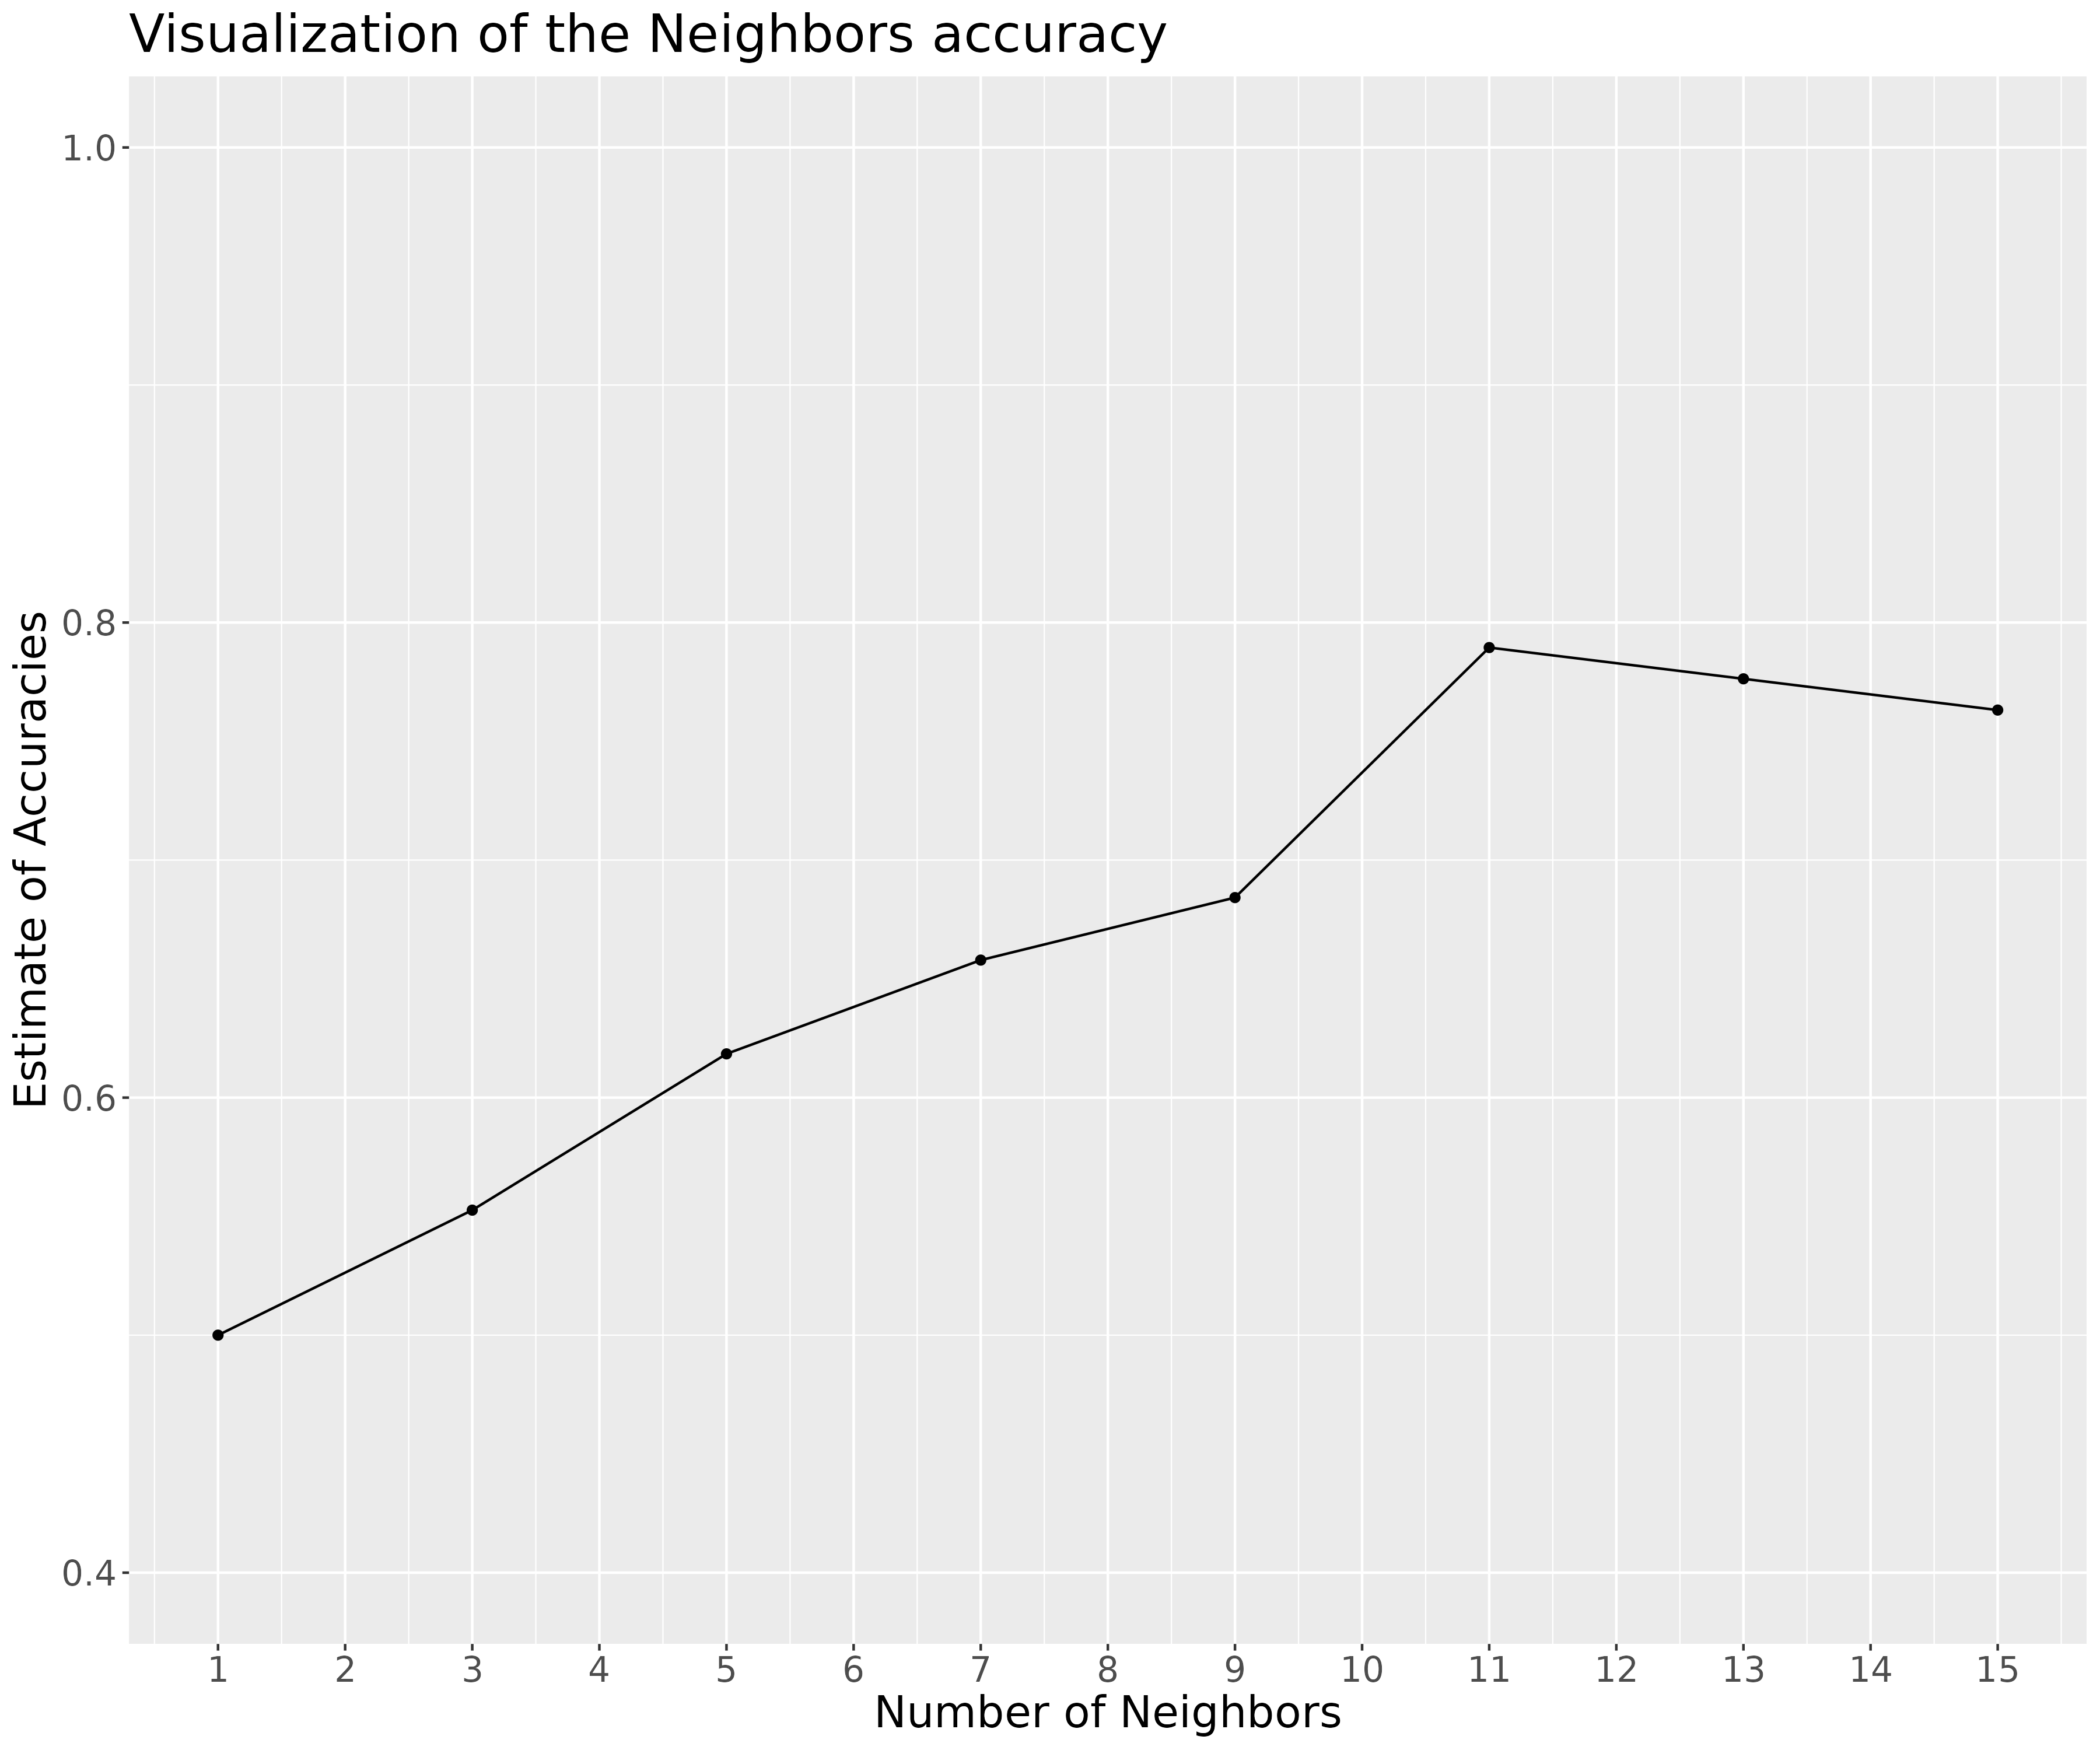

In [64]:
minecraft_accuracy<- knn_k_specification_results|> 
filter(.metric == "accuracy")

plot_of_k_values<- ggplot(minecraft_accuracy, aes(x = neighbors, y = mean))+ 
geom_point()+ 
geom_line()+ 
xlab("Number of Neighbors")+ 
ylab("Estimate of Accuracies")+ 
ggtitle("Visualization of the Neighbors accuracy")+
scale_x_continuous(breaks = seq(0, 20, by = 1)) +  
       scale_y_continuous(limits = c(0.4, 1.0))+
theme(text = element_text(size = 18))
ggsave("plot_of_k_values.png", plot = plot_of_k_values, width = 12, height = 10, dpi = 300)


IRdisplay::display_png(file = "plot_of_k_values.png")


[insert explanation of what k we are going to use and why]